## 1. Importação

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais de alto padrão
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Carregando a base tratada do Notebook 1
caminho_dados = '../data/processed/data_model/data_model.csv'
df_aed = pd.read_csv(caminho_dados, sep=';')

print(f"Base carregada para AED Visual! Formato: {df_aed.shape}")

Base carregada para AED Visual! Formato: (216734, 84)


## 2. Periculosidade Média por Rodovia

C:\Users\gabriel.athayde\AppData\Local\Temp\ipykernel_2192\543286991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


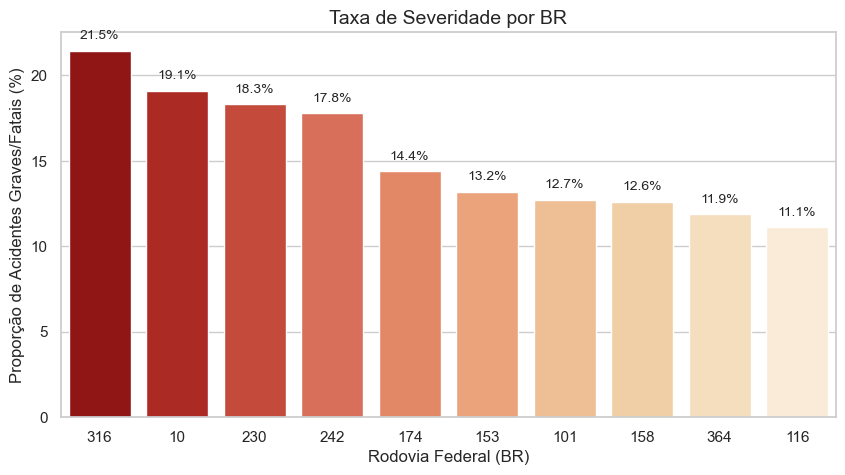

In [10]:
# Calculando a Taxa de Acidentes Graves/Fatais por BR (em %)
periculosidade_br = df_aed.groupby('br')['acidente_grave_ou_fatal'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(
    x=periculosidade_br.index, 
    y=periculosidade_br.values, 
    order=periculosidade_br.index, 
    palette='OrRd_r' # Paleta quente para indicar severidade
)

plt.title('Taxa de Severidade por BR')
plt.ylabel('Proporção de Acidentes Graves/Fatais (%)')
plt.xlabel('Rodovia Federal (BR)')

# Adicionando os rótulos
for i, valor in enumerate(periculosidade_br.values):
    plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', va='bottom', fontsize=10)

plt.show()

## 3. Qualidade da Via (ICM) vs. Severidade do Acidente

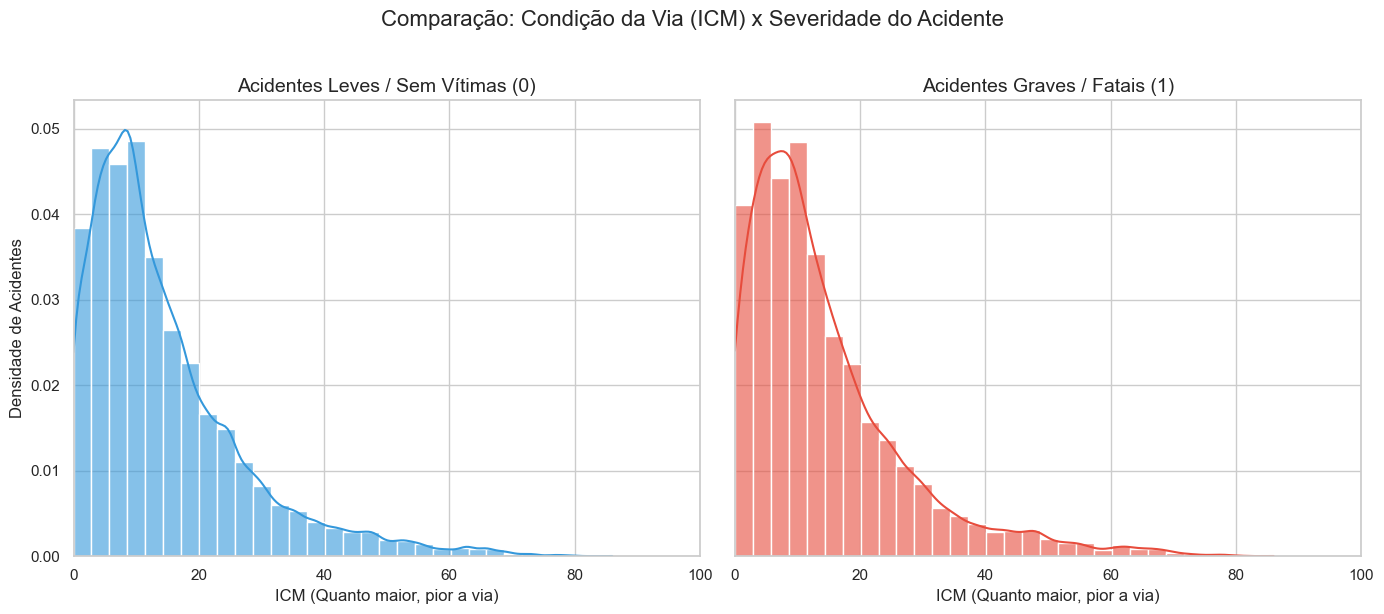

In [ ]:
# Criando uma figura com 2 gráficos lado a lado (1 linha, 2 colunas)
# sharey=True e sharex=True garantem que a escala visual seja idêntica para comparação justa
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)

# ------------------------------------------
# Gráfico 1: Acidentes Leves / Sem Vítimas (ax=axes[0])
# ------------------------------------------
sns.histplot(
    data=df_aed[df_aed['acidente_grave_ou_fatal'] == 0], 
    x='icm', 
    color='#3498db', 
    kde=True, 
    bins=30, 
    stat='density', 
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Acidentes Leves / Sem Vítimas (0)', fontsize=14)
axes[0].set_xlabel('ICM (Quanto maior, pior a via)')
axes[0].set_ylabel('Densidade de Acidentes')
axes[0].set_xlim(0, 100)

# ------------------------------------------
# Gráfico 2: Acidentes Graves / Fatais (ax=axes[1])
# ------------------------------------------
sns.histplot(
    data=df_aed[df_aed['acidente_grave_ou_fatal'] == 1], 
    x='icm', 
    color='#e74c3c', 
    kde=True, 
    bins=30, 
    stat='density', 
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Acidentes Graves / Fatais (1)', fontsize=14)
axes[1].set_xlabel('ICM (Quanto maior, pior a via)')
axes[1].set_ylabel('') # Ocultando o rótulo Y do segundo gráfico para ficar mais limpo

# Adicionando um título geral para a figura
plt.suptitle('Comparação: Condição da Via (ICM) x Severidade do Acidente', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

## 4. Correlação Direta: Degradação vs. Periculosidade no Trecho

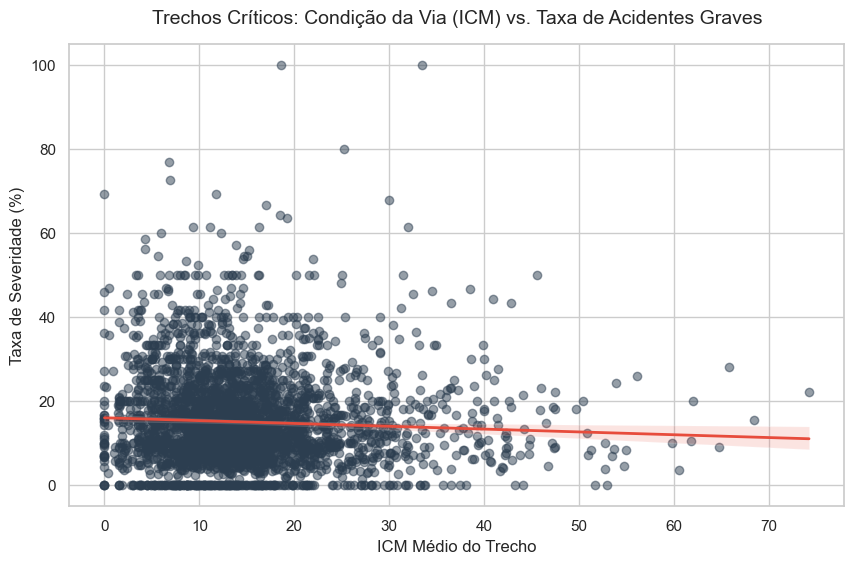

In [ ]:
# ==========================================
# 4. CORRELAÇÃO ESPAÇO-TEMPORAL MENSAL: ICM vs. SEVERIDADE
# ==========================================

# 1. Converter a coluna de texto para o formato de Data (Datetime)
# Ajuste o formato se a sua data estiver em padrão diferente (ex: dayfirst=True)
df_aed['data_inversa'] = pd.to_datetime(df_aed['data_inversa'])

# 2. Criar a coluna 'ano_mes' (ex: '2021-03') para capturar "aquele momento" exato
df_aed['ano_mes'] = df_aed['data_inversa'].dt.to_period('M')

# 3. Agrupar por BR, Quilómetro E Mês específico
trechos_mensais = df_aed.groupby(['br', 'km_join', 'ano_mes']).agg(
    total_acidentes=('acidente_grave_ou_fatal', 'count'),
    taxa_severidade=('acidente_grave_ou_fatal', 'mean'),
    icm_medio=('icm', 'mean') # O ICM reflete agora a qualidade naquele mês específico
).reset_index()

# 4. Filtrar trechos com pelo menos 2 acidentes NAQUELE MÊS para ter volume de cálculo
trechos_criticos = trechos_mensais[trechos_mensais['total_acidentes'] >= 2].copy()

# Transformar em percentagem
trechos_criticos['taxa_severidade'] = trechos_criticos['taxa_severidade'] * 100

# 5. Plotagem do gráfico de dispersão com linha de tendência
plt.figure(figsize=(10, 6))
import seaborn as sns # Garantir que o seaborn está carregado

sns.regplot(
    data=trechos_criticos, 
    x='icm_medio', 
    y='taxa_severidade',
    scatter_kws={'alpha': 0.5, 'color': '#2c3e50'}, 
    line_kws={'color': '#e74c3c', 'linewidth': 2}
)

plt.title('Trechos Críticos (Análise Mensal): Qualidade da Via vs. Taxa de Acidentes Graves', pad=15)
plt.xlabel('ICM do Trecho no Mês do Acidente (Quanto maior, pior)')
plt.ylabel('Taxa de Severidade (%)')

plt.show()